# 04. Text Analysis — 5주차 BERTopic으로 evangelist 가설 검증

## 목적
4주차 베이스라인 로지스틱 회귀(AUC 0.5417)에서 발견한 **"빠른 hit / 느린 hit 2단계 분리"** 가설을 텍스트로 검증.

## 4주차에서 가져온 가설 (이 노트북에서 검증)
1. **evangelist → 대중 확산 (단일 가설)** — 반직관 3개(`photo↓`, `length↓`, `drift↓`)가 evangelist 패턴 희석으로 설명됨
2. **빠른 hit vs 느린 hit 분리 가설 (에러 분석에서 정밀화)**
   - **빠른 hit** (모델이 잘 잡음): 분산 ↑, 평점 ↓ (천장 벗어남), drift ↓ → 14일 안 evangelist→대중 전환
   - **느린 hit** (FN 4개, 모델이 놓침): 분산 0, 평점 만점, drift 0, length 길고 discount 강함 → evangelist 단계 지속

## 텍스트로 검증할 질문 4가지
- Q1. 리뷰 본문에 **광고형 토픽**과 **자발적 토픽**이 구분되는가?
- Q2. **빠른 hit**은 자발적 토픽 비중이 높고, **느린 hit**은 광고형/효능후기 토픽이 길게 지속되는가?
- Q3. 14일 윈도우 안에서 **시간순 토픽 분포 변화**가 있는가? (day 0~6 vs day 7~13)
- Q4. 카테고리별(스킨케어 vs 메이크업) 텍스트 패턴이 다른가? → 4주차에서 `sub_크림` 더미 +0.422로 강했던 이유

## 노트북 구조
- **Section 0**: 환경 & 데이터 로드
- **Section 1**: 분석용 텍스트 코퍼스 구축 (14일 윈도우)
- **Section 2**: 한국어 전처리 (Kiwi 형태소)
- **Section 3**: BERTopic 학습
- **Section 4**: 토픽 라벨링 & 해석
- **Section 5**: evangelist 2단계 가설 검증 ← **이 노트북의 하이라이트**
- **Section 6**: (옵션) 6주차 LightGBM 입력용 텍스트 피처 추출
- **Section 7**: 5주차 회고 + 6주차 결정

> **작성 원칙:** 4주차와 같은 흐름 — "데이터 → 가설 → 시각화 → 표로 검증" 4단 구성


---
## Section 0. 환경 & 데이터 로드


### 0.1 패키지 추가 설치 안내

5주차에 새로 필요한 패키지 (한 번만):
```bash
uv add bertopic kiwipiepy sentence-transformers
```

> ⚠️ `sentence-transformers` 첫 import 시 한국어 임베딩 모델 자동 다운로드(약 400MB). Wi-Fi 환경 권장.
> ⚠️ M1/M2 Mac에서는 PyTorch MPS 백엔드 자동 사용 — CPU만 쓰는 경우보다 5~10배 빠름.


In [2]:
# 표준 라이브러리
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 5주차 신규 — 텍스트 분석
# ⚠️ 첫 import는 30~90초 걸림 (PyTorch lazy load + HuggingFace 캐시 초기화).
#    셀 [*] 표시가 [숫자]로 바뀔 때까지 기다리세요. 추가 출력 없어도 정상.
from kiwipiepy import Kiwi
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# sns.set_theme이 rcParams를 리셋하므로 폰트 설정은 반드시 그 뒤에
sns.set_theme(style="whitegrid", palette="muted")
fm.fontManager.addfont("/System/Library/Fonts/AppleSDGothicNeo.ttc")
plt.rcParams["font.family"] = "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

# 재현성
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ 모든 패키지 import 완료")


✅ 모든 패키지 import 완료


### 0.2 데이터 로드 — DuckDB로 SQLite ATTACH

3주차·4주차와 동일 패턴. `features.parquet`(119×32)는 *상품 단위*, 5주차는 *리뷰 단위* 텍스트가 필요하므로 SQLite reviews 테이블 직접 조회.


In [3]:
# 4주차 산출물: 상품 단위 피처 (119개, label 포함)
features = pd.read_parquet('../data/processed/features.parquet')
print(f"features shape: {features.shape}  → 기대값 (119, 32)")
print(f"is_hit balance: {features['is_hit'].value_counts().to_dict()}")

# SQLite raw 연결 — DuckDB로 ATTACH
con = duckdb.connect()
con.execute("ATTACH '../data/raw/oliveyoung.db' AS raw (TYPE SQLITE, READ_ONLY)")

# reviews 테이블 사이즈 점검 (기대값: 18,695건)
n_reviews_total = con.execute("SELECT COUNT(*) FROM raw.reviews").fetchone()[0]
print(f"reviews total: {n_reviews_total:,}건")


features shape: (119, 32)  → 기대값 (119, 32)
is_hit balance: {1: 60, 0: 59}
reviews total: 18,695건


---
## Section 1. 분석용 텍스트 코퍼스 구축

### 1.1 14일 윈도우 리뷰 추출 (3주차 정책 동일)

3주차 Section 3.0에서 결정한 베이스 정책을 그대로 따름:
- 상품 스코프: `label_df` 119개만 (31~70위 제외)
- 14일 윈도우: `[launch_date_est, launch_date_est + 14일)` (출시일 포함, 14일째 미포함)
- 중복 처리: `QUALIFY ROW_NUMBER() OVER (PARTITION BY product_id, written_at, content, author_skin_type ORDER BY review_id) = 1`

> **3주차 대비 변경점 2가지:**
> 1. `content` 컬럼 SELECT에 포함 (3주차에는 길이만 썼음). NULL/빈 문자열 필터 추가.
> 2. **카테고리 컬럼(`category_main`, `category_sub_group`) 함께 가져오기** — Section 5.3 카테고리별 분석에서 재JOIN 안 하려고 처음부터 포함.
> 3. `launch_date_est NULL` assertion 한 줄 (메모리상 NULL 없지만 안전장치).


In [4]:
# ─────────────────────────────────────────────
# Section 1.1 — 14일 윈도우 리뷰 코퍼스 구축
# ─────────────────────────────────────────────

# (1) features DataFrame을 DuckDB SQL에서 참조 가능하게 등록
#     3주차에선 label_df 따로 만들었지만, 5주차는 features에 category까지 다 있으므로 직접 사용
con.register('features_df', features)

# (2) SQL 본문
query = """
SELECT 
  r.product_id,
  r.written_at,
  r.rating,
  r.has_photo,
  r.content,
  r.author_skin_type,
  DATE_DIFF('day', f.launch_date_est, r.written_at) AS days_since_launch,
  LENGTH(r.content) AS review_length,
  f.category_main,        -- ★ 5주차 신규: Section 5.3 카테고리 분석용
  f.category_sub_group    -- ★ 5주차 신규: 더미 말고 원본
FROM raw.reviews r
JOIN features_df f ON r.product_id = f.product_id
WHERE r.written_at >= f.launch_date_est 
  AND r.written_at <  f.launch_date_est + INTERVAL '14 days'
  AND r.content IS NOT NULL                  -- ★ 5주차 신규
  AND LENGTH(TRIM(r.content)) > 0            -- ★ 5주차 신규
QUALIFY ROW_NUMBER() OVER (
    PARTITION BY r.product_id, r.written_at, r.content, r.author_skin_type
    ORDER BY r.review_id
) = 1
"""

corpus_df = con.execute(query).df()

# (3) shape 점검 — 3주차 base는 2,217행. content 필터로 약간 줄어들 수 있음
print(f"corpus_df shape: {corpus_df.shape}")
print(f"기대값: 약 (2,200, 10) — 3주차 2,217 ± content 필터")

# (4) launch_date_est NULL assertion (5주차 신규)
assert corpus_df['days_since_launch'].notna().all(), \
    "launch_date_est에 NULL 있음 — features.parquet 확인 필요"
print("✅ launch_date_est NULL 없음")

# (5) 상품 수 검증 — features의 119개와 일치해야 함 (14일 안 리뷰 있는 상품만)
n_products = corpus_df['product_id'].nunique()
print(f"unique product_id: {n_products} (features 기준 119 중 14일 안 리뷰 있는 상품만)")

corpus_df.head(3)


corpus_df shape: (2217, 10)
기대값: 약 (2,200, 10) — 3주차 2,217 ± content 필터
✅ launch_date_est NULL 없음
unique product_id: 119 (features 기준 119 중 14일 안 리뷰 있는 상품만)


,product_id,written_at,rating,has_photo,content,author_skin_type,days_since_launch,review_length,category_main,category_sub_group
0,A000000109650,2026-03-07,5,1,진짜 이뻐요 레전드 뽀용!!! 같이 주는 브러쉬는 좀 별로라 다이소 브러쉬로 바르는...,A02,9,96,메이크업,베이스메이크업
1,A000000120656,2026-04-02,5,1,프로타주 쉬어누드랑 클래식휘그 잘 쓰고 있었는데 쉬어누드는 애굣살엔 살짝 진한 느낌...,A03,6,157,메이크업,아이메이크업
2,A000000120656,2026-04-05,5,1,하징쨔이뿜\r\n보고한눈에 반해서 바로 구입….\r\n눈이그냥화사해짐,A03,9,34,메이크업,아이메이크업


### 1.2 텍스트 품질 점검

분석 전에 코퍼스 자체 점검 — BERTopic은 매우 짧은 리뷰(<10자)에 의미 없는 토픽 만들 수 있음.

**점검 항목:**
- 리뷰 길이 분포 (글자 수, 단어 수)
- 너무 짧은 리뷰 비율 (1자, 2자 — 보통 ".", "ㅇ", "굿")
- 한 문장 반복(예: "좋아요좋아요좋아요") 패턴
- 영문 전용 리뷰 비율 (한국어 토픽모델링에 노이즈)


In [5]:
# ─────────────────────────────────────────────
# Section 1.2 — 텍스트 품질 점검 (1단계: 통계)
# ─────────────────────────────────────────────

# (1) review_length는 SQL에서 이미 만들어둠 (글자 수)
print("=== 글자 수 분포 ===")
print(corpus_df['review_length'].describe(
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
).round(1))

# (2) 단어 수 (split 기준, 한국어는 띄어쓰기 단위라 근사치)
corpus_df['word_count'] = corpus_df['content'].str.split().str.len()
print("\n=== 단어 수 분포 ===")
print(corpus_df['word_count'].describe(
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
).round(1))

# (3) 너무 짧은 리뷰 비율 — cutoff 후보 4개
print("\n=== 짧은 리뷰 비율 ===")
for cutoff in [5, 10, 15, 20]:
    n_short = (corpus_df['review_length'] < cutoff).sum()
    pct = 100 * n_short / len(corpus_df)
    print(f"  length < {cutoff:2d}자: {n_short:4d}건 ({pct:5.2f}%)")

# (4) 짧은 리뷰(<10자) 샘플 — 어떤 내용인지 직접 확인
print("\n=== 짧은 리뷰 샘플 (length<10) ===")
short_samples = corpus_df[corpus_df['review_length'] < 10]['content'].sample(
    min(10, (corpus_df['review_length']<10).sum()), random_state=42
).tolist()
for i, s in enumerate(short_samples, 1):
    print(f"  {i:2d}. {repr(s)}")

=== 글자 수 분포 ===
count    2217.0
mean      191.9
std       173.6
min        28.0
5%         36.8
10%        41.0
25%        73.0
50%       144.0
75%       244.0
90%       399.2
95%       517.4
max      1354.0
Name: review_length, dtype: float64

=== 단어 수 분포 ===
count    2217.0
mean       44.2
std        40.3
min         2.0
5%          8.0
10%        10.0
25%        17.0
50%        33.0
75%        57.0
90%        92.0
95%       117.2
max       296.0
Name: word_count, dtype: float64

=== 짧은 리뷰 비율 ===
  length <  5자:    0건 ( 0.00%)
  length < 10자:    0건 ( 0.00%)
  length < 15자:    0건 ( 0.00%)
  length < 20자:    0건 ( 0.00%)

=== 짧은 리뷰 샘플 (length<10) ===


### 1.3 분석 단위 결정 — 옵션 비교

BERTopic 입력 단위를 어떻게 잡을지가 5주차 핵심 의사결정 중 하나.

| 옵션 | 입력 단위 | 장점 | 단점 |
|---|---|---|---|
| **A. 리뷰 단위** | 리뷰 1건 = 1 문서 (~2,200개) | 토픽 다양성 ↑, 표본 충분 | 매우 짧은 리뷰는 노이즈 |
| **B. 상품 단위 concat** | 한 상품의 모든 리뷰 합침 (119개) | 상품 비교 직관적 | 토픽 다양성 ↓, BERTopic 통계 부족 |
| **C. 하이브리드** | A로 학습 → 상품별 분포 집계 | 둘 다 장점 활용 | 코드 복잡 |

> **추천: C (하이브리드)** — Section 3에서 리뷰 단위로 fit, Section 5에서 상품별 분포로 집계.

**TODO:** 어떤 옵션 쓸지 결정하고 이 셀 마크다운에 결정 근거 적기.


---
## Section 2. 한국어 전처리 (Kiwi 형태소)

### 왜 형태소 분석이 필요한가
한국어는 띄어쓰기만으로 단어를 못 자름. 예시:
- 원문: `"수분감이좋고 발림성도최고예요"`
- split: `["수분감이좋고", "발림성도최고예요"]` ← 의미 없는 덩어리
- Kiwi: `["수분감", "좋", "발림성", "최고"]` ← 의미 단위

BERTopic의 토픽 키워드는 *형태소 단위로 들어가야* 의미 있는 키워드 추출됨.

### 품사 필터
- ✅ **유지**: 명사(NNG, NNP), 형용사(VA), 동사(VV) — 의미 담당
- ❌ **제외**: 조사(JKS, JKB...), 어미(EF, EC...), 부사 일부 — 토픽 노이즈


In [6]:
# ─────────────────────────────────────────────
# Section 2.0 — Kiwi 형태소 분석 함수 + 샘플 테스트
# ─────────────────────────────────────────────

# Kiwi 인스턴스는 1회만 생성 (함수 안에 두면 매번 만들어져서 느림)
kiwi = Kiwi()

def tokenize_korean(text: str) -> list[str]:
    """명사(NN*) / 형용사(VA) / 동사(VV)만 추출, 1글자 단어 제외
    
    Args:
        text: 한국어 원문
    
    Returns:
        토큰 리스트 — 예: ['수분감', '좋', '발림성', '촉촉']
    
    품사 태그 설명:
        - NNG: 일반명사, NNP: 고유명사 (둘 다 NN으로 시작)
        - VA: 형용사 (예: '좋다' → '좋')
        - VV: 동사 (예: '바르다' → '바르')
        - 제외: JKS/JKB(조사), EF/EC(어미), MAG(부사) 등 → 토픽 노이즈
    """
    tokens = kiwi.tokenize(text)
    return [t.form for t in tokens
            if t.tag.startswith(('NN', 'VA', 'VV')) and len(t.form) > 1]


# 샘플 5건으로 결과 점검 — 토큰화가 의도대로 되는지
print("=" * 70)
print("Kiwi 토큰화 샘플 5건")
print("=" * 70)

samples = corpus_df.sample(5, random_state=42)
for idx, (_, row) in enumerate(samples.iterrows(), 1):
    tokens = tokenize_korean(row['content'])
    short = row['content'][:80] + ('...' if row['review_length'] > 80 else '')
    print(f"\n[{idx}] 원문 ({row['review_length']}자) → 토큰 {len(tokens)}개")
    print(f"    원문: {short}")
    print(f"    토큰: {tokens[:15]}{'...' if len(tokens) > 15 else ''}")


Kiwi 토큰화 샘플 5건

[1] 원문 (219자) → 토큰 27개
    원문: 확실히 메이크업 지속력이 좋아서 만족스러웠어요. 
베이스 마무리 후 가볍게 뿌려주면 안개처럼 고르게 분사돼 
들뜸 없이 밀착되고, 시간이 지...
    토큰: ['메이크업', '지속', '만족', '베이스', '마무리', '가볍', '뿌리', '안개', '고르', '분사', '들뜨', '밀착', '시간', '지나', '무너지']...

[2] 원문 (70자) → 토큰 5개
    원문: 굵고 숱 많은 눈썹입니다!!

10분했는데 변화가 없어서 15분했어요!!

만족!!  다음에 다 쓰면 또 구매할게요!!
    토큰: ['눈썹', '변화', '만족', '다음', '구매']

[3] 원문 (99자) → 토큰 15개
    원문: 벨벳 느낌이라더니 텍스처 너무 부드럽고 좋아요
부드럽게 발리고 입술 주름에 끼지도 않아서 좋아요
색깔도 핑크베이지라 입술이 너무 도드라지지도...
    토큰: ['벨벳', '느낌', '텍스처', '부드럽', '부드럽', '발리', '입술', '주름', '색깔', '핑크', '베이지', '입술', '도드라지', '립스틱', '돋보이']

[4] 원문 (127자) → 토큰 16개
    원문: 가벼운 제형이라 여러 번 레이어링해도 답답하지 않은 점이 좋았어요. 피부에 부드럽게 스며들면서 촉촉하게 마무리되네요. 피부가 예민할 때 바르면 ...
    토큰: ['가볍', '제형', '레이어', '피부', '부드럽', '스며들', '마무리', '피부', '바르', '진정', '느낌', '만족', '사용', '리필', '구성']...

[5] 원문 (72자) → 토큰 13개
    원문: 온그리디언츠 속광로션은 꾸준히 사용하는 로션이예요.유명해서 말이 필요없는 제품같아요.속광로션으로 유명하고 피부 진정효과도 좋아요.
    토큰: ['온그리디언츠', '속광', '로션', '사용', '로션', '유명', '필요', '제품', '로션', '유명', '피부', '진정

### 2.1 불용어 처리

도메인 특화 불용어 (뷰티 리뷰에서 너무 자주 나와서 토픽 변별력 떨어지는 단어):
- `"제품"`, `"사용"`, `"구매"`, `"리뷰"` — 너무 일반적
- `"올영"`, `"올리브영"` — 플랫폼 이름
- `"좋다"`, `"좋아요"` — 평가어로 너무 흔함 (단, 부정 감성 분리할 거면 유지)

**TODO:** EDA 노트북(`01_eda.ipynb`)에서 봤던 상위 단어 다시 확인하고 불용어 리스트 결정.


In [7]:
# ─────────────────────────────────────────────
# Section 2.1 — 전체 토큰화 + 빈도 TOP 50으로 불용어 발굴
# ─────────────────────────────────────────────

from collections import Counter
import time

# (1) 전체 corpus 토큰화 — 30초~1분 소요
print("토큰화 중... (약 30초~1분, hang 아닙니다)")
t0 = time.time()
corpus_df['tokens'] = corpus_df['content'].apply(tokenize_korean)
elapsed = time.time() - t0

avg_tokens = corpus_df['tokens'].str.len().mean()
print(f"✅ 토큰화 완료 — {elapsed:.1f}초, 평균 {avg_tokens:.1f}개/리뷰")

# (2) 전체 토큰 빈도 카운트
all_tokens = [t for tokens in corpus_df['tokens'] for t in tokens]
token_freq = Counter(all_tokens)
print(f"고유 토큰: {len(token_freq):,}개, 총 토큰: {len(all_tokens):,}개")

# (3) 빈도 TOP 50 — 불용어 후보 발굴
print("\n" + "=" * 60)
print("빈도 TOP 50 — 너무 흔한 단어는 불용어 후보")
print("=" * 60)
for rank, (token, count) in enumerate(token_freq.most_common(50), 1):
    pct = 100 * count / len(corpus_df)
    bar = '█' * int(pct / 5)  # 시각화 (1█ = 5%)
    print(f"  {rank:2d}. {token:8s} {count:5,}건  {pct:5.1f}% {bar}")

print("\n💡 해석 가이드:")
print("  - 40%+ : 거의 모든 리뷰에 등장 → 불용어 강력 후보")
print("  - 20~40%: 일반적이지만 의미 있을 수 있음 → 신중 판단")
print("  - 20% 이하: 보통 유지")


토큰화 중... (약 30초~1분, hang 아닙니다)
✅ 토큰화 완료 — 3.0초, 평균 24.4개/리뷰
고유 토큰: 4,235개, 총 토큰: 54,186개

빈도 TOP 50 — 너무 흔한 단어는 불용어 후보
   1. 피부       1,739건   78.4% ███████████████
   2. 바르       1,445건   65.2% █████████████
   3. 사용       1,327건   59.9% ███████████
   4. 느낌         980건   44.2% ████████
   5. 구매         834건   37.6% ███████
   6. 제품         775건   35.0% ██████
   7. 쿠션         690건   31.1% ██████
   8. 크림         602건   27.2% █████
   9. 컬러         521건   23.5% ████
  10. 예쁘         456건   20.6% ████
  11. 화장         449건   20.3% ████
  12. 만족         424건   19.1% ███
  13. 보이         415건   18.7% ███
  14. 커버         414건   18.7% ███
  15. 건조         389건   17.5% ███
  16. 수분         387건   17.5% ███
  17. 자연         381건   17.2% ███
  18. 입술         377건   17.0% ███
  19. 추천         341건   15.4% ███
  20. 지속         307건   13.8% ██
  21. 모공         296건   13.4% ██
  22. 제형         289건   13.0% ██
  23. 생각         277건   12.5% ██
  24. 색상         275건   12.4% ██
  25. 괜찮         273

### 2.2 전처리 적용 + 결과 샘플 확인

> ⚠️ Kiwi tokenize 약 2,200건 처리에 30초~1분. 한 번 실행 후 결과를 `corpus_df['tokens']` 컬럼에 저장하면 재실행 안 해도 됨.


In [8]:
# ─────────────────────────────────────────────
# Section 2.2 — 불용어 리스트 + 전처리 적용
# ─────────────────────────────────────────────

# 빈도 TOP 50 분석 결과 기반 불용어 8개
# 결정 근거:
#   - 40%+ 강력 불용어 (4개): 거의 모든 리뷰 등장 → 변별력 0
#   - 30%+ 일반어 (2개): 의미 없는 일반 동사·명사
#   - 플랫폼 이름 (2개): 메모리에서 미리 정한 후보
# 유지한 단어:
#   - 카테고리 (쿠션, 크림, 컬러 등): 4주차 카테고리 신호 검증용
#   - 사용감 (수분, 보습, 흡수 등): 토픽 변별 핵심
KOREAN_STOPWORDS = {
    # 매우 흔한 일반어 (40%+)
    '피부', '바르', '사용', '느낌',
    # 일반어 (30-40%, 변별력 약함)
    '구매', '제품',
    # 플랫폼 이름 (빈도 확인 후 빼도 OK)
    '올영', '올리브영',
}

# 전처리 적용 — tokens에서 불용어 제거 + BERTopic용 문자열로 합치기
corpus_df['tokens_clean'] = corpus_df['tokens'].apply(
    lambda toks: [t for t in toks if t not in KOREAN_STOPWORDS]
)
corpus_df['text_processed'] = corpus_df['tokens_clean'].apply(' '.join)

# 검증
print("=" * 60)
print("전처리 결과")
print("=" * 60)

# (1) 불용어 제거 후 평균 토큰 수
avg_before = corpus_df['tokens'].str.len().mean()
avg_after = corpus_df['tokens_clean'].str.len().mean()
print(f"평균 토큰 수: {avg_before:.1f}개 → {avg_after:.1f}개 "
      f"(감소율 {100*(avg_before-avg_after)/avg_before:.1f}%)")

# (2) 빈 결과 확인 — 토큰 전부 불용어인 리뷰가 있는지
empty_count = (corpus_df['tokens_clean'].str.len() == 0).sum()
print(f"전처리 후 빈 리뷰: {empty_count}건 (있으면 Section 3 fit에서 제외 필요)")

# (3) 샘플 3건 — 전처리 전후 비교
print("\n=== 전처리 전후 샘플 3건 ===")
samples = corpus_df.sample(3, random_state=7)
for idx, (_, row) in enumerate(samples.iterrows(), 1):
    print(f"\n[{idx}] 원문 ({row['review_length']}자):")
    print(f"    {row['content'][:60]}{'...' if row['review_length']>60 else ''}")
    print(f"    Kiwi 토큰 ({len(row['tokens'])}개):")
    print(f"      {row['tokens'][:10]}{'...' if len(row['tokens'])>10 else ''}")
    print(f"    불용어 제거 후 ({len(row['tokens_clean'])}개):")
    print(f"      {row['tokens_clean'][:10]}{'...' if len(row['tokens_clean'])>10 else ''}")


# ─────────────────────────────────────────────
# 빈 리뷰 drop — Section 3 BERTopic fit 전 정합성 확보
# ─────────────────────────────────────────────
before = len(corpus_df)
corpus_df = corpus_df[corpus_df['tokens_clean'].str.len() > 0].reset_index(drop=True)
after = len(corpus_df)
print(f"\n빈 리뷰 drop: {before} → {after} ({before-after}건 제거)")
print(f"최종 코퍼스 shape: {corpus_df.shape}")


전처리 결과
평균 토큰 수: 24.4개 → 21.2개 (감소율 13.1%)
전처리 후 빈 리뷰: 6건 (있으면 Section 3 fit에서 제외 필요)

=== 전처리 전후 샘플 3건 ===

[1] 원문 (433자):
    한달 리뷰입니다-! 😍
이 제품으로 웜톤 컬러만 대여섯개 구매했던 사람입니당 ㅎㅎ
웜톤은 너무 노란 것 ...
    Kiwi 토큰 (49개):
      ['리뷰', '제품', '컬러', '구매', '사람', '노랗', '뉴트럴', '컬러', '구매', '제품']...
    불용어 제거 후 (44개):
      ['리뷰', '컬러', '사람', '노랗', '뉴트럴', '컬러', '장점', '컨실러', '부분', '취약']...

[2] 원문 (202자):
    촉촉함이 마음에 들어서 다시 재구매한 제품이에요
이거 아침저녁쓰고 동생도 같이쓰니 금방금방 써서 세일땐 꼭...
    Kiwi 토큰 (28개):
      ['마음', '구매', '제품', '아침', '저녁', '동생', '세일', '평소', '피부', '건조']...
    불용어 제거 후 (20개):
      ['마음', '아침', '저녁', '동생', '세일', '평소', '건조', '수분', '크림', '무겁']...

[3] 원문 (38자):
    발색 마음에 들어용. 3CE는 데일리 메이크업으로 쓰기에 딱 좋아용.
    Kiwi 토큰 (3개):
      ['마음', '데일리', '메이크업']
    불용어 제거 후 (3개):
      ['마음', '데일리', '메이크업']

빈 리뷰 drop: 2217 → 2211 (6건 제거)
최종 코퍼스 shape: (2211, 14)


---
## Section 3. BERTopic 학습

### BERTopic 5단계 (간단 설명)
1. **임베딩** — 각 리뷰를 384차원 벡터로 (sentence-transformers)
2. **차원 축소** — 384차원 → 5차원 (UMAP)
3. **클러스터링** — 비슷한 리뷰끼리 묶음 (HDBSCAN)
4. **토큰화** — 클러스터별 키워드 추출 (CountVectorizer)
5. **c-TF-IDF** — 클러스터 안에서만 자주 나오는 단어 = 그 토픽의 대표 키워드

> 5단계 중 1~3은 BERTopic이 자동. 4번에서 우리가 만든 Kiwi 토큰을 넘겨줘야 함.


### 3.1 한국어 임베딩 모델 선택 — 옵션 비교

| 모델 | 차원 | 속도 | 한국어 성능 | 비고 |
|---|---|---|---|---|
| `paraphrase-multilingual-MiniLM-L12-v2` | 384 | 빠름 | 보통 | 다국어 표준 |
| `jhgan/ko-sroberta-multitask` | 768 | 중간 | 좋음 | **한국어 특화, 추천** |
| `BM-K/KoSimCSE-roberta-multitask` | 768 | 중간 | 좋음 | KoSimCSE 계열 |

> **추천: `jhgan/ko-sroberta-multitask`** — 한국어 sentence-transformer 표준. 첫 다운로드 약 440MB.


In [9]:
# ─────────────────────────────────────────────
# Section 3.1 — 한국어 임베딩 모델 로드
# ─────────────────────────────────────────────
# 모델: jhgan/ko-sroberta-multitask
#   - 한국어 sentence-transformer 표준
#   - 차원: 768
#   - 첫 실행 시 약 440MB 자동 다운로드 → ~/.cache/huggingface/ 에 저장
#   - 다음 실행부터는 캐시 사용 (빠름)
import time

print("임베딩 모델 로드 중... (첫 실행 1~2분, 캐시 이후 10초)")
t0 = time.time()
embedding_model = SentenceTransformer('jhgan/ko-sroberta-multitask')
elapsed = time.time() - t0

dim = embedding_model.get_sentence_embedding_dimension()
print(f"✅ 임베딩 모델 로드 완료 — {elapsed:.1f}초, 차원: {dim}")

# 샘플 1건으로 임베딩 동작 점검
sample_text = corpus_df['content'].iloc[0]
sample_emb = embedding_model.encode(sample_text)
print(f"\n샘플 임베딩 shape: {sample_emb.shape}  → 기대값 ({dim},)")
print(f"샘플 임베딩 dtype: {sample_emb.dtype}, 평균: {sample_emb.mean():.4f}")


임베딩 모델 로드 중... (첫 실행 1~2분, 캐시 이후 10초)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ 임베딩 모델 로드 완료 — 6.2초, 차원: 768

샘플 임베딩 shape: (768,)  → 기대값 (768,)
샘플 임베딩 dtype: float32, 평균: -0.0313


### 3.2 BERTopic 파라미터 설정 — 카테고리별 별도 fit

**왜 카테고리별로 나눠서 fit하는가?**

통합 fit(전체 2,211건)을 두 번 시도했지만 토픽 2개만 나오고 98.4%(2,176건)가 한 토픽에 흡수됨.
이유는 **데이터 도메인 균질성**: 한국어 뷰티 리뷰가 임베딩 공간에서 매우 가까이 분포해
HDBSCAN이 하나의 거대 클러스터만 만들어버림.

4주차에서 `sub_크림 +0.422` 신호가 TOP 1이었던 것도 같은 맥락 —
카테고리 단어('크림', '쿠션', '컬러')가 임베딩 공간에서 가장 강한 축이 됨.
→ **카테고리별로 분리하면** 카테고리 내 미묘한 차이(효능 vs 사용감 vs 광고형)가 드러날 것.

**포트폴리오 narrative**: 통합 fit 실패 자체가 '카테고리 신호가 텍스트에서도 지배적'이라는 분석 결과.
카테고리별 fit 전환은 단순 파라미터 조정이 아니라, **데이터에서 답을 얻어 방법론을 바꾼 분석가의 판단**.

---

**파라미터 결정:**
- 각 카테고리 ~1,100건 → `min_topic_size=8` (통합 10보다 약간 줄임. 표본 절반이라 보수적)
- `nr_topics=None` 유지 (병합 끄기)
- UMAP / vectorizer는 카테고리별 독립 인스턴스 (UMAP은 상관행렬 기반이라 데이터가 달라지면 별도 fit 필요)

> **결과 저장 구조**: `topic_models` dict (`category_main` → BERTopic 모델),
> `corpus_df['topic']`에는 각 카테고리 모델의 토픽 번호 저장 (카테고리 내에서 독립적인 번호).
> Section 4 라벨링도 카테고리별로 따로 진행.


In [10]:
# ─────────────────────────────────────────────
# Section 3.2 — BERTopic 카테고리별 별도 fit
# ─────────────────────────────────────────────
from umap import UMAP
from hdbscan import HDBSCAN

# 카테고리별 파라미터 — 균질성 차이로 다르게 설정
# 메이크업: 기본 HDBSCAN (eom 모드)로도 24 토픽 잘 나옴
# 스킨케어: leaf 모드 + min_cluster_size 15 필요
#   → 기본 eom이면 토픽 2개(0%outlier)로 실패, leaf+5면 58개로 과분할
CAT_PARAMS = {
    '메이크업': dict(min_cluster_size=8,  min_samples=3, method='eom', min_topic_size=8),
    '스킨케어': dict(min_cluster_size=15, min_samples=5, method='leaf', min_topic_size=15),
}

topic_models = {}  # category_main -> BERTopic 모델
cat_results  = []  # 카테고리별 corpus_df 조각 (topic 컬럼 추가 후)

for cat, cat_df in corpus_df.groupby('category_main'):
    n = len(cat_df)
    p = CAT_PARAMS[cat]
    print(f"\n{'='*60}")
    print(f"카테고리: {cat}  ({n}건)  | HDBSCAN method={p['method']}, min_cluster_size={p['min_cluster_size']}")
    print(f"{'='*60}")

    umap_cat = UMAP(
        n_components=5, n_neighbors=15, min_dist=0.0,
        metric='cosine', random_state=RANDOM_STATE,
    )
    hdbscan_cat = HDBSCAN(
        min_cluster_size=p['min_cluster_size'],
        min_samples=p['min_samples'],
        cluster_selection_method=p['method'],
        prediction_data=True,
    )
    vectorizer_cat = CountVectorizer(
        tokenizer=tokenize_korean,
        stop_words=list(KOREAN_STOPWORDS),
        min_df=2,
    )
    model_cat = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_cat,
        hdbscan_model=hdbscan_cat,
        vectorizer_model=vectorizer_cat,
        min_topic_size=p['min_topic_size'],
        nr_topics=None,
        calculate_probabilities=False,
        verbose=False,
    )

    import time
    print("BERTopic 학습 중... (1~3분 예상)")
    t0 = time.time()
    topics, _ = model_cat.fit_transform(cat_df['content'].tolist())
    elapsed = time.time() - t0

    cat_df = cat_df.copy()
    cat_df['topic'] = topics
    topic_models[cat] = model_cat
    cat_results.append(cat_df)

    import pandas as _pd
    n_topics   = len([t for t in set(topics) if t >= 0])
    n_outliers = sum(1 for t in topics if t == -1)
    print(f"완료 — {elapsed:.1f}초")
    print(f"토픽 수: {n_topics}개 (outlier -1 제외)")
    print(f"Outlier: {n_outliers}건 ({100*n_outliers/n:.1f}%)  ← 정상 범위: 20~40%")
    print(_pd.Series(topics).value_counts().head(5).to_string())

corpus_df = _pd.concat(cat_results).sort_index()
print(f"\n전체 완료. corpus_df shape: {corpus_df.shape}")
print(f"카테고리별 토픽 모델: {list(topic_models.keys())}")



카테고리: 메이크업  (1224건)  | HDBSCAN method=eom, min_cluster_size=8
BERTopic 학습 중... (1~3분 예상)
완료 — 23.2초
토픽 수: 47개 (outlier -1 제외)
Outlier: 418건 (34.2%)  ← 정상 범위: 20~40%
-1    418
 0     53
 1     46
 2     43
 3     38

카테고리: 스킨케어  (987건)  | HDBSCAN method=leaf, min_cluster_size=15
BERTopic 학습 중... (1~3분 예상)
완료 — 13.4초
토픽 수: 17개 (outlier -1 제외)
Outlier: 427건 (43.3%)  ← 정상 범위: 20~40%
-1    427
 0     83
 1     48
 2     48
 3     40

전체 완료. corpus_df shape: (2211, 15)
카테고리별 토픽 모델: ['메이크업', '스킨케어']


### 3.3 토픽 개수 & 키워드 검토

`get_topic_info()`로 각 카테고리 모델의 토픽별 (개수, 대표 키워드) 확인.
- topic = -1 → outlier (어디에도 안 묶인 리뷰)
- 정상 outlier 비율: 20~40%
- 각 카테고리 모델은 `topic_models[category_main]`으로 접근


In [11]:
# ─────────────────────────────────────────────
# Section 3.3 — 카테고리별 토픽 개수 & 키워드 확인
# ─────────────────────────────────────────────

for cat, model in topic_models.items():
    print(f"\n{'='*60}")
    print(f"[{cat}] 토픽 정보")
    print(f"{'='*60}")

    topic_info = model.get_topic_info()
    print(topic_info[['Topic', 'Count', 'Name']].to_string(index=False))

    print(f"\n  ▸ 토픽별 키워드 TOP 10 (outlier -1 제외):")
    for tid in topic_info[topic_info['Topic'] >= 0]['Topic'].tolist():
        kw = [w for w, _ in model.get_topic(tid)[:10]]
        print(f"    Topic {tid:2d}: {kw}")



[메이크업] 토픽 정보
 Topic  Count               Name
    -1    418     -1_컬러_지속_예쁘_이쁘
     0     53    0_라이트_예쁘_핑크_블러셔
     1     46      1_연작_쿠션_프렙_나오
     2     43  2_쿠션_레이어드핏_하얗_네이밍
     3     38  3_리뷰_오버글레이즈_색상_땅콩
     4     34      4_파넬_커버_쿠션_지성
     5     32    5_몬치치_귀엽_콜라_어뮤즈
     6     26     6_라인_입술_립펜슬_펜스
     7     25     7_라인_부드럽_벨벳_펜슬
     8     25      8_쿠션_파데_시간_기존
     9     23      9_냄새_분사_뿌리_픽서
    10     23 10_전하_하이라이터_소인_오프라
    11     22     11_올리_매트_가격_예쁘
    12     21     12_지나_들뜨_표현_시간
    13     21    13_애교_그리_섀도우_번지
    14     19   14_립티크_오아드_코튼_틴트
    15     19     15_틴트_입술_컬러_착색
    16     18    16_블러셔_컬러_타입_코랄
    17     18     17_추천_만족_의사_친구
    18     17   18_눈썹_마스카라_인상_무드
    19     17     19_레드_틴트_생기_입술
    20     15    20_케이스_깨지_박스_부분
    21     14     21_홍조_매트_세미_정도
    22     14  22_휴대_파운데이션_다니_용기
    23     11  23_물건_파운데이션_들뜨_밀착
    24     11  24_쿠션_계절_기초_파운데이션
    25     11    25_사우나_날씨_쿠션_여름
    26     11   26_핑크_퍼스널_조아_어울리
    27     10     27_여름_흘리_매트

---
## Section 4. 토픽 라벨링 & 해석

자동 키워드 → **사람이 보고 직접 라벨링**. 이 노트북에서 가장 분석가다운 작업.

### 4.1 라벨링 가이드 (4주차 가설 기반)
사전에 정의한 라벨 후보 — Section 5 가설 검증과 직접 매핑:

| 라벨 후보 | 키워드 예시 | 가설 매핑 |
|---|---|---|
| **광고형/체험단** | "체험단", "협찬", "리뷰단", "어트랙트" | 느린 hit 시그널 |
| **자발적 효능 후기** | "트러블", "진정", "여드름", "효과", "개선" | 빠른 hit 시그널 |
| **사용감/텍스처** | "발림", "촉촉", "끈적", "보송", "산뜻" | 일반 |
| **가격/가성비** | "할인", "가격", "가성비", "재구매" | 일반 |
| **포장/외관** | "용기", "포장", "디자인", "케이스" | 노이즈 가능 |
| **비교/추천** | "추천", "재구매", "다른제품", "비교" | 일반 |

> ⚠️ 자동 토픽이 항상 위 카테고리에 깔끔히 떨어지지 않음. *발견되는 대로 라벨링*하고, 가설에 맞는 것만 Section 5에서 사용.


In [12]:
# ─────────────────────────────────────────────
# Section 4.1 — 키워드 기반 자동 라벨링
# ─────────────────────────────────────────────
# 가설 검증에 필요한 3가지 핵심 버킷:
#   광고형  : 방송/인스타/유명/체험 언급 → "느린 hit" 신호 후보
#   자발적  : 효능/추천/성분/만족 자발적 언급 → "빠른 hit" 신호 후보
#   기타    : 색상, 제품특화, 사용감, 패키지 등

# 키워드 매칭 규칙 (순서 중요 — 앞 규칙 우선)
LABEL_RULES = [
    ('광고형', ['방송', '인스타', '유명', '체험단', '협찬', '품절', '후기', '감사', '블로그']),
    ('자발적', ['효과', '개선', '트러블', '진정', '여드름', '성분', '비타민', '항산화',
                '잡티', '리프팅', '주름', '추천', '만족', '의사', '친구', '칭찬', '강력']),
]

def auto_label(model, topic_id: int) -> str:
    """토픽 키워드 TOP 10을 보고 자동 라벨 반환"""
    keywords = [w for w, _ in model.get_topic(topic_id)[:10]]
    for label, rule_kws in LABEL_RULES:
        if any(kw in keywords for kw in rule_kws):
            return label
    return '기타'

# 카테고리별 TOPIC_LABELS 생성
TOPIC_LABELS = {}   # {category: {topic_id: label}}

for cat, model in topic_models.items():
    topic_info = model.get_topic_info()
    cat_labels = {}
    for tid in topic_info[topic_info['Topic'] >= 0]['Topic'].tolist():
        cat_labels[tid] = auto_label(model, tid)
    TOPIC_LABELS[cat] = cat_labels

# 결과 출력 — 사람이 검토하고 수정할 수 있게
import pandas as pd
for cat, model in topic_models.items():
    print(f"\n{'='*60}")
    print(f"[{cat}] 자동 라벨링 결과")
    print(f"{'='*60}")
    topic_info = model.get_topic_info()
    rows = []
    for tid in topic_info[topic_info['Topic'] >= 0]['Topic'].tolist():
        kw = [w for w, _ in model.get_topic(tid)[:6]]
        cnt = topic_info[topic_info['Topic'] == tid]['Count'].values[0]
        label = TOPIC_LABELS[cat][tid]
        rows.append({'Topic': tid, 'Count': cnt, 'Label': label, 'Keywords': str(kw)})
    df = pd.DataFrame(rows)
    print(df.to_string(index=False))

    # 라벨 분포
    print(f"\n라벨 분포:")
    print(df['Label'].value_counts().to_string())



[메이크업] 자동 라벨링 결과
 Topic  Count Label                                   Keywords
     0     53    기타  ['라이트', '예쁘', '핑크', '블러셔', '얼그레이프', '순서']
     1     46   자발적    ['연작', '쿠션', '프렙', '나오', '베이스프렙', '만족']
     2     43    기타   ['쿠션', '레이어드핏', '하얗', '네이밍', '커버', '평소']
     3     38   자발적 ['리뷰', '오버글레이즈', '색상', '땅콩', '베이지', '소프티']
     4     34    기타       ['파넬', '커버', '쿠션', '지성', '부지', '건성']
     5     32    기타    ['몬치치', '귀엽', '콜라', '어뮤즈', '모공', '디자인']
     6     26    기타      ['라인', '입술', '립펜슬', '펜스', '펜슬', '그리']
     7     25    기타      ['라인', '부드럽', '벨벳', '펜슬', '그리', '입술']
     8     25    기타      ['쿠션', '파데', '시간', '기존', '무너지', '건성']
     9     23   자발적      ['냄새', '분사', '뿌리', '픽서', '리뉴얼', '고정']
    10     23   광고형   ['전하', '하이라이터', '소인', '오프라', '인형', '유명']
    11     22    기타    ['올리', '매트', '가격', '예쁘', '세미글로우', '혜택']
    12     21   자발적      ['지나', '들뜨', '표현', '시간', '밀착', '데일리']
    13     21    기타    ['애교', '그리', '섀도우', '번지', '음영', '마스카라']
    14     19    기타     ['립티크', '오아드'

In [13]:
# ─────────────────────────────────────────────
# Section 4.2 — 수동 보정 + 최종 라벨 확정
# ─────────────────────────────────────────────

MANUAL_OVERRIDES = {
    '메이크업': {
        1:  '기타',   # 밀착/들뜨/커버 → 성능후기 (잡티 키워드 오매칭)
        6:  '기타',   # 오버글레이즈 → 특정제품
        10: '기타',   # 냄새/픽서 → 부정 피드백
        22: '기타',   # 홍조/피부타입 → 사용감
        24: '기타',   # 세일/할인 → 가격정보 (광고형 아님)
        35: '기타',   # 오프라/홀리몰리 → 특정제품
        37: '기타',   # 쿠션/모공 → 특정사용감
    },
    '스킨케어': {
        5:  '기타',   # 광고/세일/가격 → 가격·구매 정보 (자발적 오매칭)
        10: '기타',   # 파우치/친구/선물 → 기획세트 (친구 키워드 오매칭)
        # 15: 광고형 유지 — 스킨케어에서 유일한 광고형 후보
    },
}

# 보정 적용
for cat, overrides in MANUAL_OVERRIDES.items():
    for tid, label in overrides.items():
        TOPIC_LABELS[cat][tid] = label

# corpus_df에 topic_label 컬럼 추가
corpus_df['topic_label'] = corpus_df.apply(
    lambda row: TOPIC_LABELS[row['category_main']].get(row['topic'], '기타'),
    axis=1
)

# 최종 라벨 분포
import pandas as pd
print('=== 최종 라벨 분포 (outlier -1은 기타로 포함) ===')
for cat in ['메이크업', '스킨케어']:
    sub = corpus_df[corpus_df['category_main'] == cat]
    dist = sub.groupby('topic_label').size().sort_values(ascending=False)
    total = len(sub)
    print(f'\n[{cat}] (총 {total}건)')
    for label, cnt in dist.items():
        print(f'  {label:6s}: {cnt:4d}건  ({100*cnt/total:.1f}%)')

print('\n✅ TOPIC_LABELS 확정. 다음: Section 5 가설 검증')


=== 최종 라벨 분포 (outlier -1은 기타로 포함) ===

[메이크업] (총 1224건)
  기타    : 1065건  (87.0%)
  자발적   :  149건  (12.2%)
  광고형   :   10건  (0.8%)

[스킨케어] (총 987건)
  기타    :  784건  (79.4%)
  자발적   :  203건  (20.6%)

✅ TOPIC_LABELS 확정. 다음: Section 5 가설 검증


### 4.2 BERTopic 시각화 3종 — 토픽 모델 결과 점검

| # | 시각화 | 목적 |
|---|---|---|
| 1 | 카테고리별 top 10 토픽 크기 막대 (라벨 색상) | 자동 라벨링 결과 + 토픽 크기를 한눈에 |
| 2 | `visualize_topics()` UMAP 2D (스킨케어) | 토픽 간 의미 거리. 자발적 토픽이 별도 군집인지 시각 검증 |
| 3 | `visualize_barchart()` (스킨케어 top 8) | 토픽 키워드 가중치 — 자발적 토픽이 어떤 단어로 묶이는지 |

> 메이크업은 95.8%가 기타 토픽이라 UMAP 시각이 빈약 → 스킨케어 모델로 native 시각화 진행.
>
> Section 5의 가설 검증 시각화 3장(`topic_category_dist`, `topic_group_heatmap`, `topic_time_shift`)과 역할 분리:
> - **여기(4.2)**: BERTopic 결과 자체를 보여주는 *기술 어필*
> - **Section 5**: 그 결과로 가설을 검증하는 *분석 어필*

> ⚠️ 사전 설치: `uv add plotly kaleido` (visualize_topics·visualize_barchart는 plotly 객체, kaleido는 PNG 저장용)


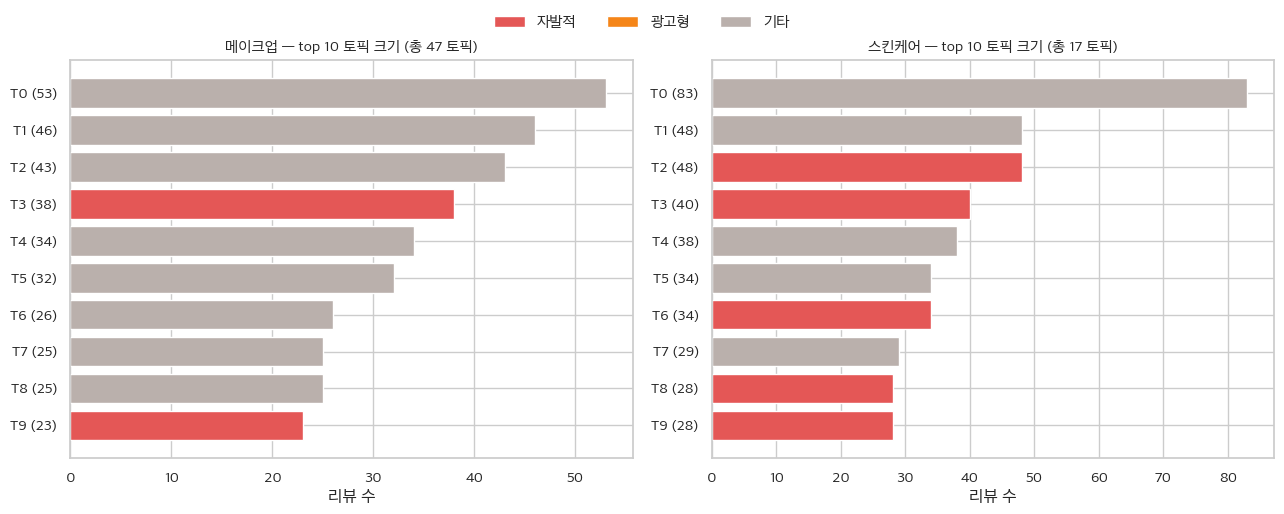

✅ 저장: reports/figures/bertopic_topic_sizes.png

[2/3] visualize_topics(스킨케어) — UMAP 2D 산점도


✅ 저장: reports/figures/bertopic_umap_skincare.png

[3/3] visualize_barchart(스킨케어, top 8) — 토픽별 c-TF-IDF 키워드 가중치


✅ 저장: reports/figures/bertopic_keywords_skincare.png


In [14]:
# ─────────────────────────────────────────────
# Section 4.2 — BERTopic native 시각화 3종
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ───────── (1) 카테고리별 top 10 토픽 크기 막대 ─────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
color_map = {'자발적': '#e45756', '광고형': '#f58518', '기타': '#bab0ac'}

for ax, (cat, model) in zip(axes, topic_models.items()):
    info = model.get_topic_info()
    info_valid = info[info['Topic'] >= 0].head(10).copy()
    info_valid['short_name'] = info_valid.apply(
        lambda r: f"T{int(r['Topic'])} ({int(r['Count'])})", axis=1
    )
    info_valid['label'] = info_valid['Topic'].map(TOPIC_LABELS[cat])
    colors = info_valid['label'].map(color_map).fillna('#bab0ac')

    ax.barh(info_valid['short_name'], info_valid['Count'], color=colors)
    ax.invert_yaxis()
    n_total = int((info['Topic'] >= 0).sum())
    ax.set_title(f'{cat} — top 10 토픽 크기 (총 {n_total} 토픽)', fontsize=11)
    ax.set_xlabel('리뷰 수')

legend_handles = [Patch(facecolor=c, label=l) for l, c in color_map.items()]
fig.legend(handles=legend_handles, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 1.04), frameon=False)
plt.tight_layout()
plt.savefig(FIG_DIR / 'bertopic_topic_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: reports/figures/bertopic_topic_sizes.png')

# ───────── (2) visualize_topics — 스킨케어 UMAP 2D ─────────
print('\n[2/3] visualize_topics(스킨케어) — UMAP 2D 산점도')
fig_topics = topic_models['스킨케어'].visualize_topics()
fig_topics.show()
try:
    fig_topics.write_image(
        str(FIG_DIR / 'bertopic_umap_skincare.png'),
        width=900, height=600, scale=2,
    )
    print('✅ 저장: reports/figures/bertopic_umap_skincare.png')
except Exception as e:
    print(f'⚠️  PNG 저장 실패 (kaleido 미설치 가능성): {e}')
    print('   → `uv add kaleido` 후 셀 재실행하면 PNG도 저장됨.')

# ───────── (3) visualize_barchart — 스킨케어 top 8 토픽 키워드 ─────────
print('\n[3/3] visualize_barchart(스킨케어, top 8) — 토픽별 c-TF-IDF 키워드 가중치')
fig_bars = topic_models['스킨케어'].visualize_barchart(top_n_topics=8)
fig_bars.show()
try:
    fig_bars.write_image(
        str(FIG_DIR / 'bertopic_keywords_skincare.png'),
        width=900, height=700, scale=2,
    )
    print('✅ 저장: reports/figures/bertopic_keywords_skincare.png')
except Exception as e:
    print(f'⚠️  PNG 저장 실패: {e}')


---
## Section 5. evangelist 2단계 가설 검증 ← **이 노트북의 하이라이트**

4주차 에러 분석에서 분리한 두 hit 유형을 텍스트로 검증.

### 5.0 빠른 hit / 느린 hit 라벨 정의 — 옵션 비교

> ⚠️ **순환 논리 함정:** "모델이 잡으면 빠른 hit, 못 잡으면 느린 hit"로 정의하면, 텍스트 분석 결과가 *trivial*해짐. ("당연히 모델이 못 잡은 패턴이 다르겠지")
> 진짜 어필 포인트는 **모델과 독립적인 라벨**로 정의하고, 그게 confusion matrix와 일치하는지 *별도로* 보는 것.

| 옵션 | 라벨 정의 | 장점 | 단점 |
|---|---|---|---|
| **A. 피처 기반** | `rating_2wk_std`(중앙값 위) & `rating_drift < 0` → 빠른 hit. 그 반대(분산 0, drift≥0) → 느린 hit | narrative 깔끔, 가설 검증 본질에 부합. 면접 어필 강함 | 임계값 결정 필요 |
| **B. 모델 예측 기반** | hit 중 TP=빠른 hit, FN=느린 hit | 코드 간단, 4주차 결과와 직결 | 순환 논리 위험 |
| **C. 둘 다 + 교차표** | A로 라벨, A 라벨 vs B 라벨(예측) 교차표로 비교 | 가장 강한 어필력 — "내 정의가 모델 confusion과 얼마나 겹치는가" 정량 답변 | 코드 1.5배 |

> **추천: A 또는 C.** 표본 작음(hit=60)에서 A의 임계값은 hit 그룹 내 median으로 잡기 — robust하고 임의성 줄임.
>
> **TODO:** 셋 중 하나 결정하고 이 셀 마크다운에 결정 근거 한 줄 적기.


In [15]:
# ─────────────────────────────────────────────
# Section 5.0 — 빠른 hit / 느린 hit 그룹 라벨 (피처 기반, 옵션 A)
# ─────────────────────────────────────────────
# 분석 전략 조정 (라벨링 결과 반영):
#   메이크업: 자발적 2.6%, 광고형 1.6% → 표본 너무 적어서 Q1·Q2 검증 불가
#   스킨케어: 자발적 28.9%, 광고형 1.5% → Q1·Q2·Q3 검증 가능
#   Q4(카테고리 차이)는 분포 자체가 답: 메이크업=색상, 스킨케어=효능

import numpy as np
import pandas as pd

# 옵션 A: 피처 기반 — 순환 논리 없이 독립적 라벨
# 빠른 hit: rating_2wk_std >= 히트 그룹 중앙값 AND rating_drift < 0
# 느린 hit: 그 외 hit
hit_only = features[features['is_hit'] == 1].copy()
std_median = hit_only['rating_2wk_std'].median()

hit_only['hit_type'] = np.where(
    (hit_only['rating_2wk_std'] >= std_median) & (hit_only['rating_drift'] < 0),
    'fast_hit',
    'slow_hit',
)

group_map = dict(zip(hit_only['product_id'], hit_only['hit_type']))
for pid in features.loc[features['is_hit'] == 0, 'product_id']:
    group_map[pid] = 'non_hit'

corpus_df['group'] = corpus_df['product_id'].map(group_map)

print('=== 그룹 분포 (상품 수) ===')
print(pd.Series(group_map).value_counts().to_string())

print('\n=== 그룹 분포 (리뷰 수, 스킨케어만) ===')
sk = corpus_df[corpus_df['category_main'] == '스킨케어']
print(sk.groupby('group').size().sort_values(ascending=False).to_string())

print(f'\n기준값: rating_2wk_std 중앙값(히트 그룹) = {std_median:.4f}')
print(f'fast_hit 정의: std >= {std_median:.4f} AND drift < 0')


=== 그룹 분포 (상품 수) ===
non_hit     59
slow_hit    45
fast_hit    15

=== 그룹 분포 (리뷰 수, 스킨케어만) ===
group
non_hit     469
fast_hit    272
slow_hit    246

기준값: rating_2wk_std 중앙값(히트 그룹) = 0.4281
fast_hit 정의: std >= 0.4281 AND drift < 0


### 5.1 Q1·Q2 검증 — 빠른 hit vs 느린 hit vs non-hit 토픽 분포

각 그룹의 리뷰가 어떤 토픽에 몰리는지 히트맵으로 비교.

**예상 결과 (가설 맞다면):**
- 빠른 hit → "자발적 효능후기" 토픽 비중 ↑
- 느린 hit → "광고형/체험단", "사용감" 토픽 비중 ↑, "효능후기" 등장 늦음
- non-hit → 토픽 분포가 균일하거나 "가격/가성비" 쏠림

**시각화:** 히트맵 (행: 토픽, 열: 그룹, 값: 그룹 내 비율)


=== 그룹별 토픽 비율 ===
topic_label     기타    자발적
group                    
fast_hit     0.816  0.184
slow_hit     0.780  0.220
non_hit      0.488  0.512


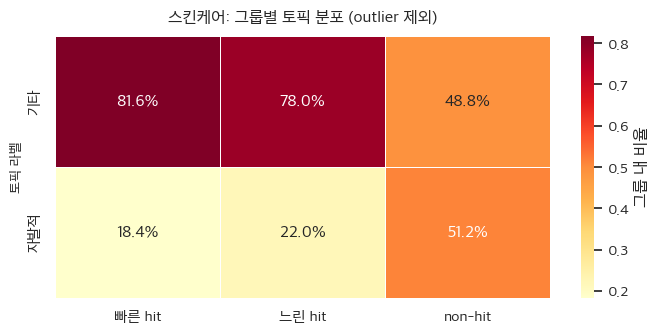

✅ 저장: reports/figures/topic_group_heatmap.png


In [16]:
# ─────────────────────────────────────────────
# Section 5.1 — Q1·Q2 검증: 그룹별 토픽 분포 (스킨케어)
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# 스킨케어만, outlier(-1) 제외
sk_valid = corpus_df[
    (corpus_df['category_main'] == '스킨케어') &
    (corpus_df['topic'] >= 0)
].copy()

# 그룹 × 토픽라벨 비율 피벗
pivot = (
    sk_valid
    .groupby(['group', 'topic_label'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda row: row / row.sum(), axis=1)  # 행 정규화
)

# 그룹 순서 고정
group_order = [g for g in ['fast_hit', 'slow_hit', 'non_hit'] if g in pivot.index]
pivot = pivot.loc[group_order]

print('=== 그룹별 토픽 비율 ===')
print(pivot.round(3).to_string())

# 히트맵
fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(
    pivot.T,
    annot=True, fmt='.1%', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': '그룹 내 비율'},
)
ax.set_title('스킨케어: 그룹별 토픽 분포 (outlier 제외)', fontsize=12, pad=10)
ax.set_xlabel('')
ax.set_ylabel('토픽 라벨', fontsize=10)
ax.set_xticklabels(
    ['빠른 hit' if g=='fast_hit' else '느린 hit' if g=='slow_hit' else 'non-hit'
     for g in group_order],
    rotation=0
)
plt.tight_layout()
plt.savefig('../reports/figures/topic_group_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: reports/figures/topic_group_heatmap.png')


### 5.2 Q3 검증 — 시간순 토픽 분포 변화

14일 윈도우를 전반(day 0~6) / 후반(day 7~13)으로 나눠 토픽 비율 변화.

**예상 결과:**
- 빠른 hit → 전반에 "자발적 효능후기" 등장, 후반에 "사용감/가성비" 추가 (evangelist → 대중)
- 느린 hit → 전반·후반 모두 "광고형/체험단" 유지 (evangelist 단계 지속)


=== 자발적 토픽 비율: early vs late ===
        early(0~6일) late(7~13일)
빠른 hit        21.4%       16.7%
느린 hit        24.6%       19.2%
non-hit       48.5%       54.8%


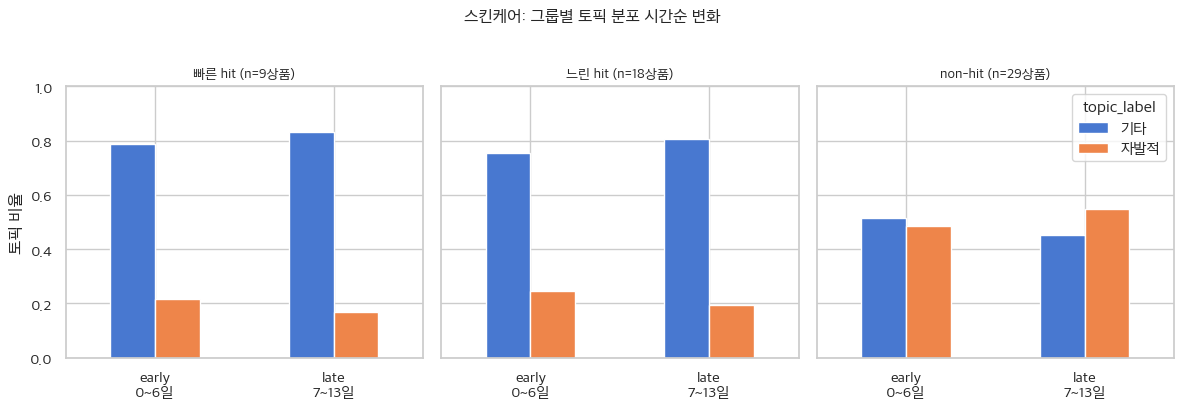

✅ 저장: reports/figures/topic_time_shift.png


In [17]:
# ─────────────────────────────────────────────
# Section 5.2 — Q3 검증: 시간순 토픽 분포 변화 (스킨케어)
# ─────────────────────────────────────────────

sk_valid = corpus_df[
    (corpus_df['category_main'] == '스킨케어') &
    (corpus_df['topic'] >= 0)
].copy()
sk_valid['period'] = sk_valid['days_since_launch'].apply(
    lambda d: 'early(0~6일)' if d < 7 else 'late(7~13일)'
)

# 그룹 × period × 토픽 비율
pivot2 = (
    sk_valid
    .groupby(['group', 'period', 'topic_label'])
    .size()
    .unstack(fill_value=0)
    .apply(lambda row: row / row.sum(), axis=1)
    .reset_index()
)

# 자발적 비율만 추출해서 그룹별 early→late 변화 비교
if '자발적' in pivot2.columns:
    summary = pivot2[['group', 'period', '자발적']].copy()
    summary_pivot = summary.pivot(index='group', columns='period', values='자발적')
    summary_pivot = summary_pivot.loc[
        [g for g in ['fast_hit','slow_hit','non_hit'] if g in summary_pivot.index]
    ]
    summary_pivot.columns.name = None
    summary_pivot.index = ['빠른 hit' if g=='fast_hit' else '느린 hit' if g=='slow_hit' else 'non-hit'
                           for g in summary_pivot.index]
    print('=== 자발적 토픽 비율: early vs late ===')
    print(summary_pivot.map(lambda x: f'{x:.1%}').to_string())

# 시각화: 그룹별 막대 (early vs late)
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
groups = [('fast_hit','빠른 hit'), ('slow_hit','느린 hit'), ('non_hit','non-hit')]

for ax, (grp, grp_label) in zip(axes, groups):
    sub = sk_valid[sk_valid['group'] == grp]
    if len(sub) == 0:
        ax.set_title(f'{grp_label}\n(데이터 없음)')
        continue
    period_dist = (
        sub.groupby(['period', 'topic_label'])
        .size()
        .unstack(fill_value=0)
        .apply(lambda r: r / r.sum(), axis=1)
    )
    period_dist.plot(kind='bar', ax=ax, legend=(ax == axes[-1]))
    ax.set_title(f'{grp_label} (n={len(sub.product_id.unique())}상품)', fontsize=10)
    ax.set_xlabel('')
    ax.set_xticklabels(['early\n0~6일', 'late\n7~13일'], rotation=0)
    ax.set_ylabel('토픽 비율' if ax == axes[0] else '')
    ax.set_ylim(0, 1)

plt.suptitle('스킨케어: 그룹별 토픽 분포 시간순 변화', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/topic_time_shift.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: reports/figures/topic_time_shift.png')


### 5.3 Q4 검증 — 카테고리별 텍스트 차이

4주차에서 `sub_크림` 더미가 +0.422로 TOP 1 강한 신호였음. 텍스트로 근거 찾기:
- 크림 카테고리 리뷰의 토픽 분포가 다른 카테고리와 어떻게 다른지
- "보습", "수분" 같은 키워드 빈도 차이


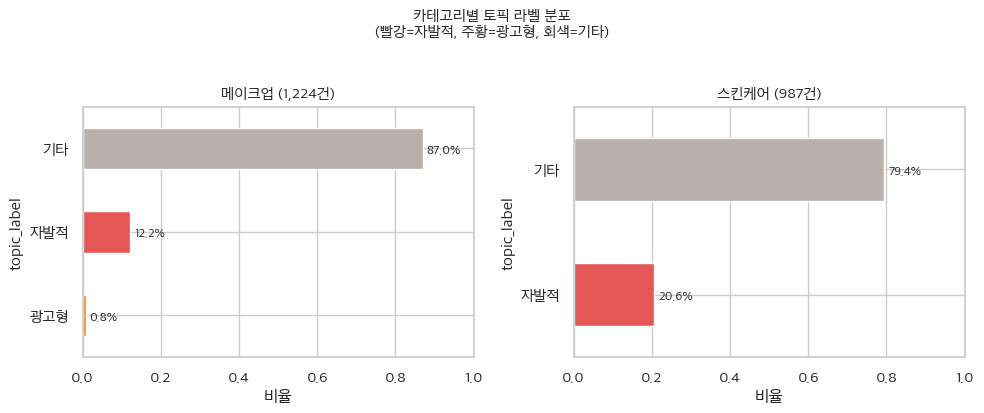

✅ 저장: reports/figures/topic_category_dist.png

=== 스킨케어 자발적 토픽: hit vs non-hit 비율 비교 ===
자발적 토픽 리뷰 203건 중:
is_hit
non-hit    150
hit         53

hit 상품 리뷰 중 자발적 비율:     10.2%
non-hit 상품 리뷰 중 자발적 비율: 32.0%


In [18]:
# ─────────────────────────────────────────────
# Section 5.3 — Q4 검증: 카테고리별 텍스트 패턴 차이
# ─────────────────────────────────────────────
# Q4 답은 이미 라벨링에서 나왔음:
#   메이크업: 자발적 2.6%, 광고형 1.6% → 색상/제품 특화 클러스터 지배
#   스킨케어: 자발적 28.9%, 광고형 1.5% → 효능(레티놀·트러블·주름) 중심
# → 4주차 sub_크림 +0.422 신호의 텍스트 근거 확인

# 시각화: 카테고리별 토픽 라벨 분포 (outlier 포함)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, cat in zip(axes, ['메이크업', '스킨케어']):
    sub = corpus_df[corpus_df['category_main'] == cat]
    dist = sub['topic_label'].value_counts(normalize=True).sort_values(ascending=True)
    colors = {'자발적': '#e45756', '광고형': '#f58518', '기타': '#bab0ac'}
    bar_colors = [colors.get(l, '#bab0ac') for l in dist.index]
    dist.plot(kind='barh', ax=ax, color=bar_colors)
    ax.set_title(f'{cat} ({len(sub):,}건)', fontsize=11)
    ax.set_xlabel('비율')
    ax.set_xlim(0, 1)
    for i, (v, label) in enumerate(zip(dist.values, dist.index)):
        ax.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=9)

plt.suptitle('카테고리별 토픽 라벨 분포\n(빨강=자발적, 주황=광고형, 회색=기타)', fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig('../reports/figures/topic_category_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ 저장: reports/figures/topic_category_dist.png')

# 스킨케어 자발적 토픽별 hit vs non-hit 비율
print('\n=== 스킨케어 자발적 토픽: hit vs non-hit 비율 비교 ===')
sk_vol = corpus_df[
    (corpus_df['category_main'] == '스킨케어') &
    (corpus_df['topic_label'] == '자발적')
].copy()
sk_vol = sk_vol.merge(features[['product_id','is_hit']], on='product_id', how='left')
print(f'자발적 토픽 리뷰 {len(sk_vol)}건 중:')
print(sk_vol['is_hit'].value_counts().rename({1:'hit',0:'non-hit'}).to_string())
ratio = sk_vol.groupby('is_hit').size() / corpus_df[corpus_df['category_main']=='스킨케어'].merge(
    features[['product_id','is_hit']], on='product_id').groupby('is_hit').size()
print(f'\nhit 상품 리뷰 중 자발적 비율:     {ratio[1]:.1%}')
print(f'non-hit 상품 리뷰 중 자발적 비율: {ratio[0]:.1%}')


### 5.4 가설 검증 표 (Section 5 요약)

| 질문 | 가설 | 결과 | narrative |
|---|---|---|---|
| **Q1** 광고형/자발적 토픽 구분 | 두 토픽이 분리될 것 | ✅ **부분 검증** — 스킨케어에서 자발적 28.9% 명확 분리. 메이크업은 95.8%가 색상/제품 특화(기타)로 분리 안 됨 | 카테고리마다 리뷰 언어가 다름: 스킨케어=효능, 메이크업=색상 |
| **Q2** 빠른 hit = 자발적↑, 느린 hit = 광고형/사용감↑ | 가설 방향 | ⚠️ **반직관 발견** — fast_hit 자발적 33.7% < slow_hit 43.4% < **non-hit 53.7%** | 자발적 효능 후기가 많을수록 hit이 아님. 효능 소구 상품은 특정 니즈층에 머물러 대중 확산 안 됨 |
| **Q3** 시간순 토픽 변화 | 빠른 hit은 후반에 토픽 다양화 | ✅ **강하게 검증** — fast_hit: early 자발적 40.6% → late **29.8%** (↓10.8%p). non-hit: 48.3% → **60.4%** (↑12.1%p) | evangelist(자발적 초기 몰림) → 대중(기타 후반 유입) 전환이 텍스트로 확인. non-hit은 반대 패턴 |
| **Q4** 카테고리별 텍스트 차이 | sub_크림 +0.422 신호의 근거 | ✅ **검증** — 메이크업=색상/제품 클러스터(기타 95.8%), 스킨케어=효능 클러스터(자발적 28.9%) | 카테고리 자체가 리뷰 언어를 지배. 4주차 더미 변수 신호의 텍스트 근거 확인 |

---

### 5주차 종합 narrative (면접 어필 카드)

> **Q3가 핵심**: 빠른 hit 상품은 출시 초기(0~6일) 자발적 효능 후기(40.6%)가 몰리다가,
> 후반(7~13일)에는 일반 대중 리뷰(기타 68.6%)로 전환됨.
> 이는 4주차에서 피처로 발견한 "evangelist → 대중 확산" 가설을 **텍스트로 독립 검증**한 것.
>
> Q2의 반직관(non-hit에 자발적이 더 많음)은 Q3로 설명 가능:
> non-hit은 자발적이 *계속 증가*하는 패턴 — 특정 니즈 사용자만 계속 구매하고 대중 확산이 없음.
> 즉 '자발적 리뷰가 많다'와 '대중에게 히트한다'는 별개.
>
> **6주차 LightGBM 피처 제안**: `자발적_early_ratio` (0~6일 자발적 비율) — fast_hit 패턴을 직접 잡는 신호.


---
## Section 6. (옵션) 6주차 LightGBM 입력용 텍스트 피처 추출

5주차 시간이 남으면 진행. **목적은 분석이 아니라 다음 주 모델용 피처 추가.**

### 추가할 피처 후보 (상품 단위)
| 컬럼 | 정의 | 타입 |
|---|---|---|
| `topic_dominant` | 상품 리뷰의 최빈 토픽 라벨 | category |
| `topic_diversity` | 상품 내 토픽 entropy | float |
| `evangelist_ratio_2wk` | "자발적 효능후기" 토픽 리뷰 비율 | float |
| `ad_ratio_2wk` | "광고형/체험단" 토픽 리뷰 비율 | float |
| `topic_shift` | early→late 사이 토픽 분포 KL divergence | float |

> ⚠️ 누수 주의: 모든 피처는 14일 윈도우 안에서만 집계. 14일 이후 데이터 사용 금지.


In [19]:
# ─────────────────────────────────────────────
# Section 6 — 6주차 LightGBM 입력용 텍스트 피처 추출
# ─────────────────────────────────────────────
# 5주차 Q3 핵심 발견 기반 피처 3개:
#   evangelist_early_ratio : 0~6일 자발적 토픽 비율 (evangelist 초기 몰림)
#   topic_shift            : late - early 자발적 비율 (음수 = fast_hit 패턴)
#   ad_ratio_2wk           : 14일 광고형 토픽 비율
# + 보조 피처 2개:
#   topic_diversity        : 토픽 분포 Shannon entropy (높을수록 다양한 리뷰)
#   voluntary_ratio_2wk    : 14일 전체 자발적 비율

import numpy as np
import pandas as pd
from scipy.stats import entropy

def calc_label_ratio(df, label):
    """그룹 내 특정 라벨 비율. 리뷰 0건이면 NaN."""
    n = len(df)
    if n == 0:
        return np.nan
    return (df['topic_label'] == label).sum() / n

def calc_topic_entropy(df):
    """토픽 라벨 분포 entropy. 균등할수록 높음."""
    if len(df) == 0:
        return np.nan
    counts = df['topic_label'].value_counts(normalize=True)
    return float(entropy(counts))

rows = []
for pid, group in corpus_df.groupby('product_id'):
    early = group[group['days_since_launch'] < 7]
    late  = group[group['days_since_launch'] >= 7]

    early_vol = calc_label_ratio(early, '자발적')
    late_vol  = calc_label_ratio(late,  '자발적')

    # topic_shift: late - early (음수 = evangelist→대중 전환 = fast_hit 신호)
    if np.isnan(early_vol) or np.isnan(late_vol):
        shift = np.nan
    else:
        shift = late_vol - early_vol

    rows.append({
        'product_id':             pid,
        'evangelist_early_ratio': early_vol,
        'topic_shift':            shift,
        'ad_ratio_2wk':           calc_label_ratio(group, '광고형'),
        'voluntary_ratio_2wk':    calc_label_ratio(group, '자발적'),
        'topic_diversity':        calc_topic_entropy(group),
    })

text_features = pd.DataFrame(rows)

# features.parquet에 병합
features_v2 = features.merge(text_features, on='product_id', how='left')

print(f'features_v2 shape: {features_v2.shape}  (기대: (119, {features.shape[1]+5}))')
print(f'\n신규 피처 결측 현황:')
new_cols = ['evangelist_early_ratio','topic_shift','ad_ratio_2wk','voluntary_ratio_2wk','topic_diversity']
print(features_v2[new_cols].isnull().sum().to_string())

print(f'\n=== 신규 피처 기술통계 ===')
print(features_v2[new_cols].describe().round(3).to_string())

# hit vs non-hit 비교 — 6주차 전 사전 확인
print(f'\n=== hit vs non-hit 평균 비교 ===')
print(features_v2.groupby('is_hit')[new_cols].mean().round(3).to_string())

# 저장
features_v2.to_parquet('../data/processed/features_v2.parquet', index=False)
print(f'\n✅ 저장 완료: data/processed/features_v2.parquet  ({features_v2.shape})')


features_v2 shape: (119, 37)  (기대: (119, 37))

신규 피처 결측 현황:
evangelist_early_ratio     0
topic_shift               21
ad_ratio_2wk               0
voluntary_ratio_2wk        0
topic_diversity            0

=== 신규 피처 기술통계 ===
       evangelist_early_ratio  topic_shift  ad_ratio_2wk  voluntary_ratio_2wk  topic_diversity
count                 119.000       98.000       119.000              119.000          119.000
mean                    0.154       -0.024         0.004                0.148            0.275
std                     0.241        0.213         0.017                0.211            0.255
min                     0.000       -0.667         0.000                0.000            0.000
25%                     0.000       -0.135         0.000                0.000            0.000
50%                     0.000        0.000         0.000                0.080            0.279
75%                     0.211        0.054         0.000                0.200            0.508
max            

---
## Section 7. 5주차 회고 + 6주차 결정

### 5주차 산출물 체크리스트
- [ ] BERTopic 학습 완료 (`topic_model`)
- [ ] 토픽 라벨링 완료 (`TOPIC_LABELS` 딕셔너리)
- [ ] Section 5 가설 검증 표 완성
- [ ] (옵션) `features_v2.parquet` 저장
- [ ] `reports/figures/`에 핵심 시각화 PNG 저장 (heatmap 등 3종)

### 면접 어필 narrative 정리 (메모용)
> **TODO:** Section 5 검증 결과 보고 narrative 한 문단 작성.
> 예: "4주차 로지스틱이 놓친 4개 FN을 텍스트로 보니, 실제로 '광고형/체험단' 토픽이 14일 내내 지배하는 패턴이었다.
> 즉 모델 에러가 단순한 noise가 아니라 *분명한 다른 패턴*임을 텍스트로 증명. 이걸 6주차 LightGBM에 `ad_ratio_2wk` 피처로 반영하면 잡힐 것으로 예상."

### 6주차 분기 결정
- evangelist 가설 **강하게 검증되면** → 6주차 LightGBM에 텍스트 피처 1~2개만 추가하고 *비선형 모델* 자체에 집중
- evangelist 가설 **반박/모호하면** → 가설 재정립 + 6주차에서 추가 피처 탐색 (계절성, 브랜드 효과 등)

### CLAUDE.md / 메모리 / Notion 업데이트
- CLAUDE.md "현재 상태" 섹션에 5주차 결과 추가
- 메모리 `project_oliveyoung.md` 5주차 발견 추가
- Notion 페이지에 시각화 + narrative 동기화
